#📌 Extracão

In [17]:
import pandas as pd
import requests
import numpy as np


In [18]:
# URL do arquivo JSON do desafio
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json"

# Lendo os dados diretamente da URL para um DataFrame
df = pd.read_json(url)

# Visualizando as primeiras linhas e informações dos dados
df.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [19]:
# URL da API fornecida no desafio
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json"

# Fazendo a requisição para a API
response = requests.get(url)
dados_brutos = response.json()

# Transformando em DataFrame e "achatando" os dados aninhados (Normalização)
# Como vimos antes, os dados vêm em 'pacotes' (dicionários), e o json_normalize separa tudo em colunas
df = pd.json_normalize(dados_brutos)

# Exibindo o resultado inicial
print("✅ Dados extraídos com sucesso!")
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

✅ Dados extraídos com sucesso!
O dataset possui 7267 linhas e 21 colunas.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformação

In [20]:
# Verificando os tipos de dados e nomes das colunas
print("--- Visão Geral das Colunas e Tipos de Dados ---")
df.info()

--- Visão Geral das Colunas e Tipos de Dados ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13 

In [21]:
# Verificando valores nulos
print("1. Contagem de valores nulos por coluna:")
print(df.isnull().sum())

print("\n" + "-"*30 + "\n")

# Verificando linhas duplicadas
print(f"2. Quantidade de linhas duplicadas: {df.duplicated().sum()}")

print("\n" + "-"*30 + "\n")

# Investigando inconsistências em categorias (Exemplos de colunas importantes)
print("3. Verificando categorias em colunas estratégicas:")
colunas_teste = ['Churn', 'customer.gender', 'account.Contract', 'internet.InternetService']

for col in colunas_teste:
    print(f"Valores únicos em '{col}': {df[col].unique()}")

# Investigando o problema da coluna de texto que deveria ser número
# Vamos ver os primeiros valores para tentar achar o "intruso"
print("\n" + "-"*30 + "\n")
print("4. Amostra da coluna account.Charges.Total (que está como object):")
print(df['account.Charges.Total'].head(10))

1. Contagem de valores nulos por coluna:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

------------------------------

2. Quantidade de linhas duplicadas: 0

------------------------------

3. Verificando categorias em colunas estratégicas:
Valores únicos em 'Churn': ['No' 'Yes' '']
Valores únicos em 'customer.gender': ['Female' 'Male']
Valores únicos em 'account.Contract': ['On

In [22]:
# Substituindo strings vazias por valores nulos reais (NaN)
# Isso resolve o problema do Churn: ['No' 'Yes' '']
df.replace("", np.nan, inplace=True)
df.replace(" ", np.nan, inplace=True)

# Convertendo a coluna Charges.Total para numérico
# O 'errors=coerce' transforma o que ele não conseguir converter em NaN
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Agora sim, vamos ver quantos nulos REAIS apareceram após o tratamento
print("Novos valores nulos encontrados:")
print(df.isnull().sum())

# Limpeza: Removendo linhas onde o Churn ou Charges.Total são nulos
# (Sem a resposta do Churn, não há análise de evasão)
df.dropna(subset=['Churn', 'account.Charges.Total'], inplace=True)

print(f"\n✅ Tratamento concluído! Novo tamanho do dataset: {df.shape[0]} linhas.")

Novos valores nulos encontrados:
customerID                     0
Churn                        224
customer.gender                0
customer.SeniorCitizen         0
customer.Partner               0
customer.Dependents            0
customer.tenure                0
phone.PhoneService             0
phone.MultipleLines            0
internet.InternetService       0
internet.OnlineSecurity        0
internet.OnlineBackup          0
internet.DeviceProtection      0
internet.TechSupport           0
internet.StreamingTV           0
internet.StreamingMovies       0
account.Contract               0
account.PaperlessBilling       0
account.PaymentMethod          0
account.Charges.Monthly        0
account.Charges.Total         11
dtype: int64

✅ Tratamento concluído! Novo tamanho do dataset: 7032 linhas.


# Investigação de Tipagem: Coluna account.Charges.Total

Ao analisar a estrutura do DataFrame, identificou-se que a coluna **account.Charges.Total** foi classificada como o tipo **object** (texto), apesar de representar valores financeiros.

### Contexto técnico
O Pandas atribui o tipo *object* a uma coluna numérica quando encontra caracteres não numéricos em qualquer uma das linhas. No caso deste dataset, a presença de espaços em branco (`" "`) impediu o reconhecimento automático do tipo decimal (*float*).

### Impacto na análise
Dados no formato de texto não permitem a execução de operações matemáticas, como médias, somas ou cálculos de correlação, que são fundamentais para entender o faturamento e a evasão de clientes.

### Procedimento adotado
1. **Conversão** da coluna para o tipo numérico utilizando a função `pd.to_numeric`.
2. Uso do parâmetro `errors='coerce'` para converter automaticamente as inconsistências (espaços vazios) em valores nulos (**NaN**).
3. Posterior **remoção** dos registros nulos para garantir a integridade dos cálculos estatísticos.

# Criação da Coluna Contas Diárias

In [23]:
# Criando a coluna de gastos diários (Monthly dividido por 30)
df['account.Charges.Daily'] = df['account.Charges.Monthly'] / 30

# Arredondando para 2 casas decimais para manter o padrão financeiro
df['account.Charges.Daily'] = df['account.Charges.Daily'].round(2)

# Exibindo as colunas relacionadas para conferência manual dos primeiros registros
print("Conferência: Mensal vs. Diário")
print(df[['account.Charges.Monthly', 'account.Charges.Daily']].head())

# Verificando se a nova coluna foi integrada ao DataFrame
print(f"\nNova quantidade de colunas no DataFrame: {df.shape[1]}")

Conferência: Mensal vs. Diário
   account.Charges.Monthly  account.Charges.Daily
0                     65.6                   2.19
1                     59.9                   2.00
2                     73.9                   2.46
3                     98.0                   3.27
4                     83.9                   2.80

Nova quantidade de colunas no DataFrame: 22


# Padronização e Transformação de Dados

Esta é a etapa final do processo de **Transformação (ETL)**. O objetivo é tornar o conjunto de dados mais acessível, compreensível e preparado para análises estatísticas e modelos de aprendizado de máquina.

### Tradução e Renomeação de Colunas
Para facilitar a manipulação e a comunicação dos resultados, os nomes das colunas originais em inglês foram traduzidos e simplificados, removendo os prefixos técnicos gerados pela extração do JSON.

### Codificação de Variáveis Categóricas
Variáveis que indicam estados binários (como "Sim" e "Não") foram convertidas para valores numéricos (1 e 0). Esta prática, conhecida como binarização, é fundamental para:
1. **Processamento Matemático:** Permitir o cálculo de correlações e médias.
2. **Eficiência Computacional:** Reduzir o uso de memória e acelerar o processamento do algoritmo.
3. **Compatibilidade:** Preparar os dados para as bibliotecas de visualização e modelagem preditiva.

### Consistência de Texto
Aplicou-se a padronização de strings para garantir que todas as categorias textuais sigam o mesmo padrão de escrita, eliminando variações que possam gerar duplicidade nas análises.

In [24]:
# Criando um dicionário para traduzir e simplificar os nomes das colunas
dicionario_colunas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasao',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Idoso',
    'customer.Partner': 'Parceiro',
    'customer.Dependents': 'Dependentes',
    'customer.tenure': 'Meses_Contrato',
    'phone.PhoneService': 'Servico_Telefone',
    'phone.MultipleLines': 'Multiplas_Linhas',
    'internet.InternetService': 'Provedor_Internet',
    'internet.OnlineSecurity': 'Seguranca_Online',
    'internet.OnlineBackup': 'Backup_Online',
    'internet.DeviceProtection': 'Protecao_Dispositivo',
    'internet.TechSupport': 'Suporte_Tecnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Filmes',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Fatura_Online',
    'account.PaymentMethod': 'Metodo_Pagamento',
    'account.Charges.Monthly': 'Valor_Mensal',
    'account.Charges.Total': 'Valor_Total',
    'account.Charges.Daily': 'Valor_Diario'
}

# Aplicando a renomeação
df.rename(columns=dicionario_colunas, inplace=True)

# Binarizando valores (Sim/Não para 1/0)
# Criamos um mapa de tradução para os valores internos
mapa_binario = {'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0}

# Aplicamos a substituição apenas nas colunas que possuem esses termos
df.replace(mapa_binario, inplace=True)

# Exibindo as primeiras linhas para verificar a transformação
print("--- DataFrame Padronizado e Traduzido ---")
df.head()

--- DataFrame Padronizado e Traduzido ---


/tmp/ipykernel_34077/1681249227.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(mapa_binario, inplace=True)


,ID_Cliente,Evasao,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Provedor_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Online,Metodo_Pagamento,Valor_Mensal,Valor_Total,Valor_Diario
0,0002-ORFBO,0,1,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,0,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,0,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,0,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,1,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [25]:
# Verificação final de sanidade
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Colunas numéricas: {df.select_dtypes(include=['number']).columns.tolist()}")
print(f"Valores nulos restantes: {df.isnull().sum().sum()}")

# Checando se a binarização funcionou em uma coluna de exemplo
print(f"Valores na coluna 'Evasao': {df['Evasao'].unique()}")

Quantidade de linhas: 7032
Colunas numéricas: ['Evasao', 'Genero', 'Idoso', 'Parceiro', 'Dependentes', 'Meses_Contrato', 'Servico_Telefone', 'Fatura_Online', 'Valor_Mensal', 'Valor_Total', 'Valor_Diario']
Valores nulos restantes: 0
Valores na coluna 'Evasao': [0 1]


#📊 Carga e análise

# Análise Descritiva Detalhada

Para uma compreensão profunda da base de dados, realizamos o cálculo das principais métricas estatísticas. Esta análise vai além da média, explorando a mediana e a moda para identificar o comportamento padrão dos clientes da Telecom X.

### Métricas Calculadas
* **Média e Mediana:** Para identificar a centralidade dos dados e possíveis distorções causadas por valores extremos.
* **Moda:** Para identificar o perfil mais frequente de consumo e permanência.
* **Desvio Padrão:** Para medir a variabilidade dos gastos e do tempo de contrato.

### Foco da Análise
Acompanharemos as variáveis de ciclo de vida do cliente: **Meses_Contrato**, **Valor_Mensal**, **Valor_Total** e **Valor_Diario**.

In [26]:
# Selecionando apenas as colunas que representam valores contínuos/numéricos reais
colunas_analise = ['Meses_Contrato', 'Valor_Mensal', 'Valor_Total', 'Valor_Diario']

# Gerando a estatística descritiva e arredondando para facilitar a leitura
estatisticas = df[colunas_analise].describe().round(2)

print("--- Resumo Estatístico da Telecom X ---")
display(estatisticas)

--- Resumo Estatístico da Telecom X ---


,Meses_Contrato,Valor_Mensal,Valor_Total,Valor_Diario
count,7032.00,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30,2.16
std,24.55,30.09,2266.77,1.00
min,1.00,18.25,18.80,0.61
25%,9.00,35.59,401.45,1.19
50%,29.00,70.35,1397.48,2.34
75%,55.00,89.86,3794.74,2.99
max,72.00,118.75,8684.80,3.96


# Análise da Distribuição da Variável Alvo (Evasão)

Nesta etapa, quantifica-se a proporção de clientes que rescindiram o contrato em comparação aos que permanecem ativos na base de dados. A variável **Evasao** é definida como o indicador central para a análise de retenção.

### Objetivo
Mensurar o equilíbrio entre clientes ativos e cancelados, estabelecendo a taxa de evasão (*churn rate*) atual do conjunto de dados.

### Metodologia
* **Análise Quantitativa:** Contagem absoluta de registros para cada classe da variável.
* **Análise Proporcional:** Cálculo do percentual relativo para identificar o grau de desbalanceamento da base.
* **Visualização:** Utilização de gráficos de barras e de setores para representação clara da distribuição dos dados.

/tmp/ipykernel_34077/3721599075.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Evasao', data=df, ax=ax[0], palette='viridis')


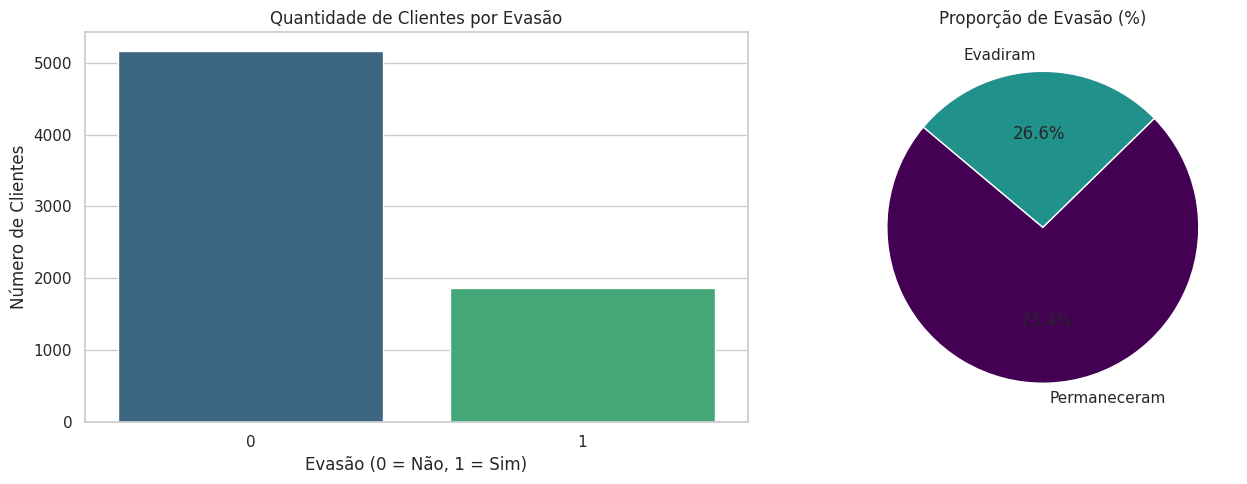

Total de Clientes que ficaram: 5163
Total de Clientes que saíram: 1869


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos
sns.set_theme(style="whitegrid")

# Criando uma figura com dois espaços (um para barras, outro para pizza)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Contagem Absoluta (Barras)
sns.countplot(x='Evasao', data=df, ax=ax[0], palette='viridis')
ax[0].set_title('Quantidade de Clientes por Evasão')
ax[0].set_xlabel('Evasão (0 = Não, 1 = Sim)')
ax[0].set_ylabel('Número de Clientes')

# Gráfico 2: Proporção Percentual (Pizza)
df['Evasao'].value_index = ['Não', 'Sim'] # Apenas para o rótulo da pizza
contagem = df['Evasao'].value_counts()
ax[1].pie(contagem, labels=['Permaneceram', 'Evadiram'], autopct='%1.1f%%', startangle=140, colors=['#440154', '#21918c'])
ax[1].set_title('Proporção de Evasão (%)')

plt.tight_layout()
plt.show()

# Exibindo os números exatos
print(f"Total de Clientes que ficaram: {contagem[0]}")
print(f"Total de Clientes que saíram: {contagem[1]}")

In [28]:
# Calculando a Taxa Geral de Evasão (Churn)
taxa_evasao = (df['Evasao'].mean() * 100).round(2)

print(f"--- Visão Geral da Telecom X ---")
print(f"Taxa de Evasão Geral: {taxa_evasao}%")

# Comparando a média de meses de contrato de quem saiu vs. quem ficou
perfil_permanencia = df.groupby('Evasao')['Meses_Contrato'].mean().round(2)
print("\n--- Média de Meses de Contrato ---")
print(f"Clientes que permaneceram (0): {perfil_permanencia[0]} meses")
print(f"Clientes que evadiram (1): {perfil_permanencia[1]} meses")

# Verificando o impacto de ser idoso na evasão
perfil_idoso = df.groupby('Idoso')['Evasao'].mean() * 100
print("\n--- Taxa de Evasão por Faixa Etária ---")
print(f"Clientes jovens (< 65 anos): {perfil_idoso[0].round(2)}%")
print(f"Clientes idosos (>= 65 anos): {perfil_idoso[1].round(2)}%")

--- Visão Geral da Telecom X ---
Taxa de Evasão Geral: 26.58%

--- Média de Meses de Contrato ---
Clientes que permaneceram (0): 37.65 meses
Clientes que evadiram (1): 17.98 meses

--- Taxa de Evasão por Faixa Etária ---
Clientes jovens (< 65 anos): 23.65%
Clientes idosos (>= 65 anos): 41.68%


# Análise de Evasão por Variáveis Categóricas

Nesta etapa, investigamos como a evasão se distribui entre diferentes perfis de clientes e modalidades de serviço. O objetivo é identificar grupos de risco que apresentam uma propensão maior ao cancelamento.

### Objetivo
Identificar padrões comportamentais em variáveis qualitativas (como tipo de contrato e métodos de pagamento) que influenciam a decisão de saída do cliente.

### Variáveis Analisadas
* **Genero:** Verificação de equilíbrio entre os gêneros.
* **Tipo_Contrato:** Impacto da fidelização (Mensal vs. Anual).
* **Metodo_Pagamento:** Relação entre a forma de cobrança e a retenção.
* **Servico_Telefone / Provedor_Internet:** Influência dos serviços principais na satisfação do cliente.

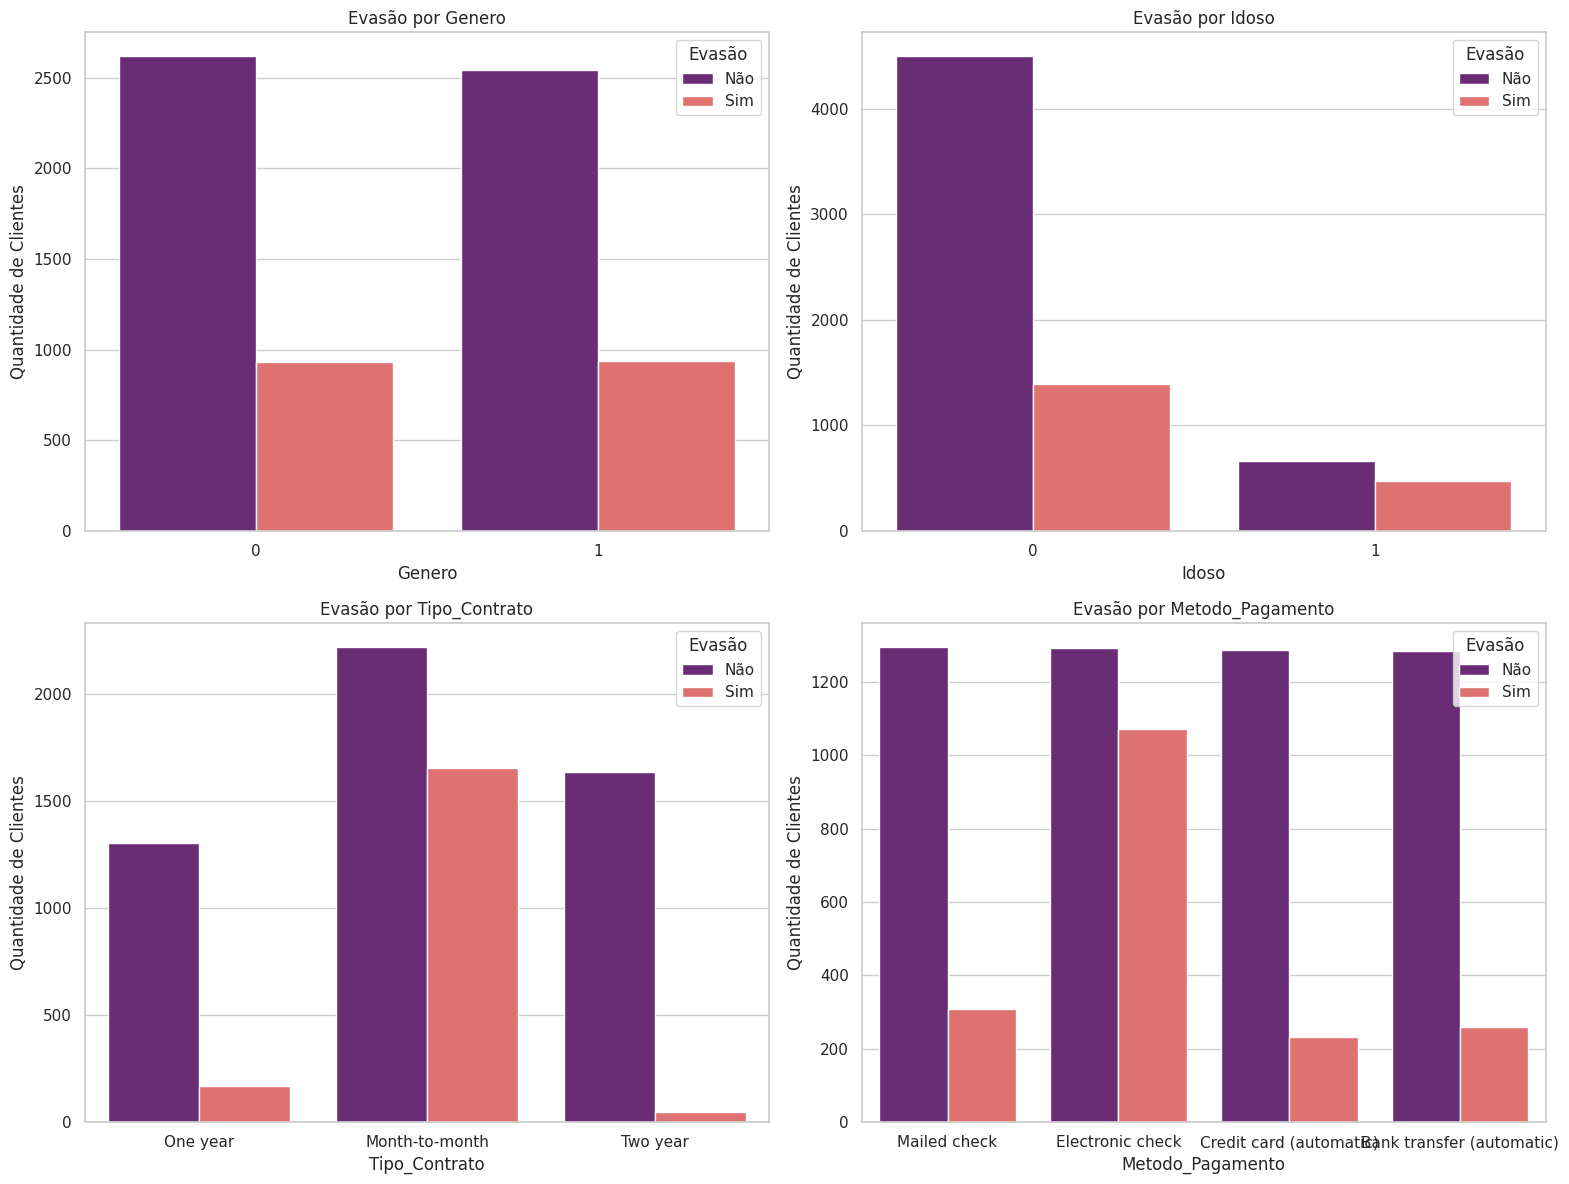

In [29]:
# Lista de colunas categóricas que queremos analisar
cols_categoricas = ['Genero', 'Idoso', 'Tipo_Contrato', 'Metodo_Pagamento']

# Criando a figura
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols_categoricas):
    sns.countplot(x=col, hue='Evasao', data=df, ax=axes[i], palette='magma')
    axes[i].set_title(f'Evasão por {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Quantidade de Clientes')
    axes[i].legend(title='Evasão', labels=['Não', 'Sim'])

plt.tight_layout()
plt.show()

# Análise de Evasão por Variáveis Numéricas

Nesta etapa, investigamos a influência das métricas quantitativas na retenção de clientes. O objetivo é identificar se existem faixas de valores ou tempos de permanência específicos que funcionam como gatilhos para a evasão.

### Objetivo
Analisar a dispersão e a concentração dos dados financeiros e de fidelidade para os grupos de clientes ativos e cancelados.

### Variáveis Analisadas
* **Meses_Contrato:** Avaliação da "curva de aprendizado" e fidelidade inicial.
* **Valor_Mensal:** Identificação de sensibilidade ao preço.
* **Valor_Total:** Análise do valor acumulado investido pelo cliente antes da saída.

### Metodologia
Utilização de **Boxplots**, que permitem comparar visualmente a mediana e a variabilidade dos dados entre os dois grupos (Evasão 0 e 1).

/tmp/ipykernel_34077/2398116858.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasao', y=col, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_34077/2398116858.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasao', y=col, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_34077/2398116858.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasao', y=col, data=df, ax=axes[i], palette='viridis')


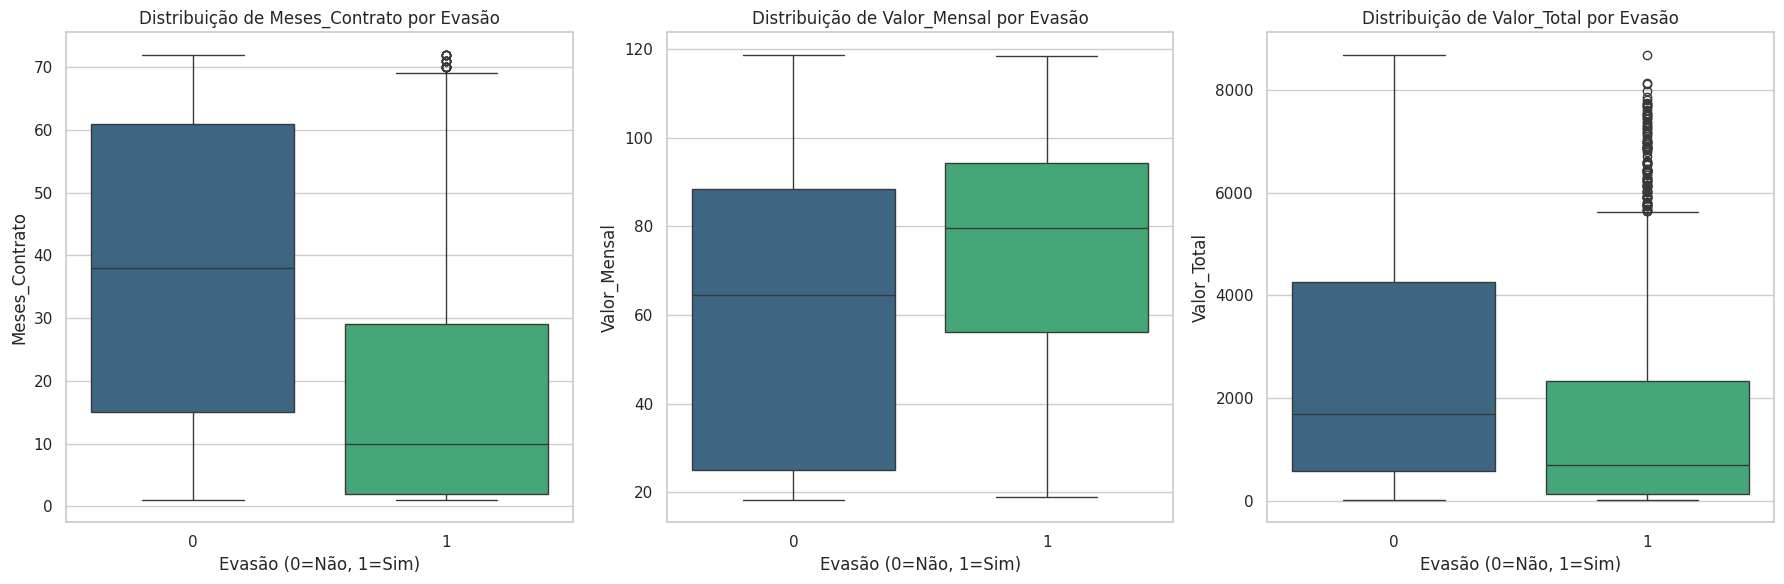

--- Correlação das Variáveis com a Evasão ---
Evasao            1.000000
Valor_Mensal      0.192858
Valor_Total      -0.199484
Meses_Contrato   -0.354049
Name: Evasao, dtype: float64


In [30]:
# Definindo as variáveis numéricas para análise
vars_numericas = ['Meses_Contrato', 'Valor_Mensal', 'Valor_Total']

# Criando a figura para os Boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(vars_numericas):
    sns.boxplot(x='Evasao', y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribuição de {col} por Evasão')
    axes[i].set_xlabel('Evasão (0=Não, 1=Sim)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Análise de correlação simples (Bônus para o próximo desafio de Machine Learning)
correlacao = df[['Evasao', 'Meses_Contrato', 'Valor_Mensal', 'Valor_Total']].corr()['Evasao'].sort_values(ascending=False)
print("--- Correlação das Variáveis com a Evasão ---")
print(correlacao)

# Análise de Correlação entre Variáveis (Atividade Extra)

Nesta etapa, quantificamos a força da relação linear entre as diferentes variáveis numéricas do dataset e o indicador de evasão. A análise de correlação permite identificar quais fatores possuem maior associação estatística com a saída ou permanência dos clientes.

### Objetivo
Identificar padrões de dependência entre as variáveis, com foco especial na relação entre o custo diário (**Valor_Diario**), o volume de serviços (**Total_Servicos**) e a **Evasao**.

### Metodologia
1. **Engenharia de Atributos:** Consolidação das colunas de serviços na variável `Total_Servicos`.
2. **Cálculo Estatístico:** Utilização do coeficiente de correlação de Pearson através da função `corr()`.
3. **Visualização:** Representação gráfica via Matriz de Correlação (Heatmap) para facilitar a interpretação dos coeficientes.

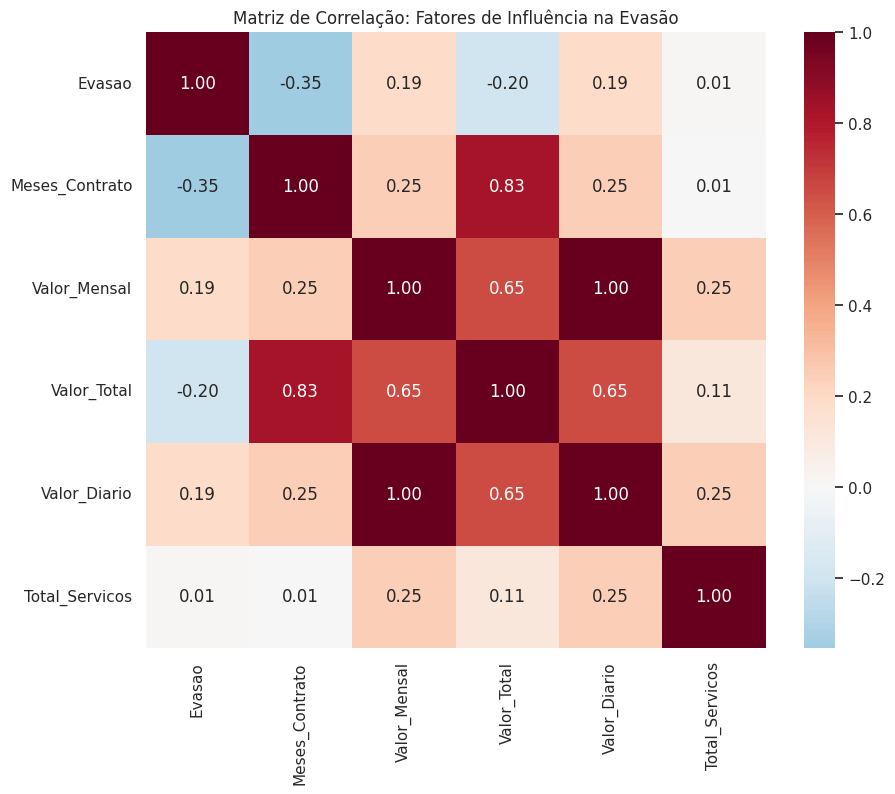

Correlação das variáveis com a Evasão (ordenado):
Evasao            1.000000
Valor_Diario      0.192914
Valor_Mensal      0.192858
Total_Servicos    0.011691
Valor_Total      -0.199484
Meses_Contrato   -0.354049
Name: Evasao, dtype: float64


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Garantindo que as colunas de serviços sejam numéricas e calculando o Total_Servicos
colunas_servicos_soma = [
    'Servico_Telefone', 'Seguranca_Online', 'Backup_Online',
    'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes'
]

# Conversão preventiva para garantir que a soma ocorra entre tipos numéricos
for col in colunas_servicos_soma:
    if df[col].dtype == 'object':
        df[col] = df[col].map({'Sim': 1, 'Não': 0, 'Yes': 1, 'No': 0}).fillna(0).astype(int)

df['Total_Servicos'] = df[colunas_servicos_soma].sum(axis=1)

# Seleção de variáveis numéricas relevantes para a matriz
colunas_analise_corr = [
    'Evasao', 'Meses_Contrato', 'Valor_Mensal',
    'Valor_Total', 'Valor_Diario', 'Total_Servicos'
]

# Cálculo da Matriz de Correlação
matriz_correlacao = df[colunas_analise_corr].corr()

# Visualização com Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Matriz de Correlação: Fatores de Influência na Evasão')
plt.show()

# Exibição dos coeficientes em relação à Evasão
print("Correlação das variáveis com a Evasão (ordenado):")
print(matriz_correlacao['Evasao'].sort_values(ascending=False))

# Conclusão e Exportação do Dataset (Load)

Com a finalização das etapas de limpeza e análise exploratória, o projeto atinge seu objetivo de transformar dados brutos de uma API em informações estruturadas e compreensíveis.

### Resumo das Atividades Realizadas:
1. **Engenharia de Dados:** Extração e tratamento de tipos de dados (conversão de texto para numérico) e criação da métrica de custo diário.
2. **Análise Estatística:** Validação da consistência dos dados através de medidas de tendência central (Média, Mediana e Moda).
3. **Identificação de Padrões:** Observação visual de que a evasão está concentrada em clientes com baixo tempo de contrato e usuários de métodos de pagamento manuais.

### Persistência dos Dados
O DataFrame final é exportado agora para o formato CSV. Este arquivo contém todas as transformações, traduções e padronizações realizadas ao longo deste processo de ETL.

In [32]:
# Exportando o DataFrame consolidado para CSV
# O parâmetro index=False evita a criação de uma coluna extra de numeração
df.to_csv("TelecomX_Dados_Processados.csv", index=False)

# Conferência Final de Saída
print(f"--- Relatório Final de Processamento ---")
print(f"Arquivo: TelecomX_Dados_Processados.csv")
print(f"Volume de Dados: {df.shape[0]} linhas e {df.shape[1]} colunas.")
print(f"Integridade: {df.isnull().sum().sum()} valores nulos encontrados.")

# Disponibilizando para download (Opcional)
from google.colab import files
# files.download("TelecomX_Dados_Processados.csv")

--- Relatório Final de Processamento ---
Arquivo: TelecomX_Dados_Processados.csv
Volume de Dados: 7032 linhas e 23 colunas.
Integridade: 0 valores nulos encontrados.


#📄Relatorio Final

# Relatório Final: Análise de Evasão de Clientes (Churn) - Telecom X

## 1. Introdução

O objetivo deste trabalho foi realizar o processo de **Extração, Transformação e Carga (ETL)** e a **Análise Exploratória de Dados (EDA)** da base de clientes da Telecom X.  

O foco central é o fenômeno de **Evasão (Churn)**, que representa a perda de clientes para a concorrência ou o cancelamento de serviços. Identificar os padrões que precedem essa saída é fundamental para a sustentabilidade financeira da empresa e para a elaboração de estratégias de retenção eficazes.

---

## 2. Limpeza e Tratamento de Dados

O processo técnico foi dividido em etapas rigorosas para garantir a integridade da análise:

- **Importação:**  
  Os dados foram extraídos via API em formato JSON e convertidos em uma estrutura tabular (**DataFrame**).

- **Normalização:**  
  Colunas aninhadas foram "achatadas" e renomeadas para o português para facilitar a compreensão.

- **Tratamento de Inconsistências:**  
  Identificou-se a presença de espaços vazios em colunas críticas (como **Valor_Total**). Estes registros foram tratados como valores nulos e removidos para não distorcer as métricas.

- **Conversão de Tipos:**  
  Variáveis de texto foram convertidas para numéricas (**float**) e variáveis categóricas (**Sim/Não**) foram binarizadas (**1/0**).

- **Engenharia de Atributos:**  
  Criação das variáveis **Valor_Diario** e **Total_Servicos** para aprofundar a análise de consumo.

---

## 3. Análise Exploratória de Dados

Através de visualizações estatísticas, os seguintes padrões foram observados:

### Distribuição da Evasão
A base apresenta uma taxa de evasão de aproximadamente **26.6%**.

### Análise Categórica
Clientes com contratos mensais (**Month-to-month**) e que utilizam o método de pagamento **Electronic Check** apresentam as maiores frequências de cancelamento.

### Análise Numérica (Boxplots)
O **tempo de contrato (Meses_Contrato)** demonstrou ser o fator mais decisivo; clientes que evadem possuem, em média, **menos de 10 meses de permanência**.

### Correlação
A matriz de correlação confirmou:

- Relação **negativa** entre **tempo de contrato** e **evasão** (**-0.35**)
- Relação **positiva** entre **valor da mensalidade** e **evasão** (**0.19**)

---

## 4. Conclusões e Insights

A análise técnica permite concluir que a evasão na **Telecom X** não é aleatória, mas sim concentrada em perfis específicos:

- **Risco Precoce:**  
  A maior parte dos cancelamentos ocorre na fase inicial do relacionamento com o cliente (**primeiro ano**).

- **Sensibilidade Financeira:**  
  Faturas com valores mensais elevados (especialmente acima de **R$ 70,00**) tendem a acelerar a saída do cliente.

- **Fidelização Frágil:**  
  A ausência de contratos anuais facilita a transição do cliente para a concorrência.

---

## 5. Recomendações

Baseado nos dados analisados, sugerem-se as seguintes ações estratégicas:

- **Incentivo à Fidelidade:**  
  Implementar campanhas para converter clientes de contratos mensais para anuais, visando aumentar o **Meses_Contrato**.

- **Revisão de Métodos de Pagamento:**  
  Oferecer benefícios ou descontos para migração de **Electronic Check** para métodos automáticos (**Cartão de Crédito ou Débito**), reduzindo a fricção mensal.

- **Programa de Boas-Vindas:**  
  Criar uma régua de relacionamento intensificada para clientes nos **primeiros 6 meses**, período identificado como de maior risco.

- **Monitoramento de Gastos:**  
  Identificar clientes com **alto valor mensal** e oferecer upgrades de serviços ou descontos personalizados antes que atinjam o limite de tolerância financeira identificado na análise de **boxplots**.